In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

path = '/content/drive/MyDrive/Colab Notebooks/cybersec_ml_mgr/cybersecurity_intrusion_data.csv'

try:
    df_drive = pd.read_csv(path)
    display(df_drive.head())
except Exception as e:
    print(f"{e}")

,session_id,network_packet_size,protocol_type,login_attempts,session_duration,encryption_used,ip_reputation_score,failed_logins,browser_type,unusual_time_access,attack_detected
0,SID_00001,599,TCP,4,492.983263,DES,0.606818,1,Edge,0,1
1,SID_00002,472,TCP,3,1557.996461,DES,0.301569,0,Firefox,0,0
2,SID_00003,629,TCP,3,75.044262,DES,0.739164,2,Chrome,0,1
3,SID_00004,804,UDP,4,601.248835,DES,0.123267,0,Unknown,0,1
4,SID_00005,453,TCP,5,532.540888,AES,0.054874,1,Firefox,0,0


In [4]:
print(df_drive.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   session_id           9537 non-null   object 
 1   network_packet_size  9537 non-null   int64  
 2   protocol_type        9537 non-null   object 
 3   login_attempts       9537 non-null   int64  
 4   session_duration     9537 non-null   float64
 5   encryption_used      7571 non-null   object 
 6   ip_reputation_score  9537 non-null   float64
 7   failed_logins        9537 non-null   int64  
 8   browser_type         9537 non-null   object 
 9   unusual_time_access  9537 non-null   int64  
 10  attack_detected      9537 non-null   int64  
dtypes: float64(2), int64(5), object(4)
memory usage: 819.7+ KB
None


In [5]:
df_drive['encryption_used'] = df_drive['encryption_used'].fillna('Unknown')

df_drive = df_drive.drop(columns=['session_id'])

kolumny_do_zakodowania = ['protocol_type', 'encryption_used', 'browser_type']
df_cleaned = pd.get_dummies(df_drive, columns=kolumny_do_zakodowania, drop_first=True)

print("Struktura po czyszczeniu i kodowaniu:")
print(df_cleaned.info())
display(df_cleaned.head())

Struktura po czyszczeniu i kodowaniu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9537 entries, 0 to 9536
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   network_packet_size      9537 non-null   int64  
 1   login_attempts           9537 non-null   int64  
 2   session_duration         9537 non-null   float64
 3   ip_reputation_score      9537 non-null   float64
 4   failed_logins            9537 non-null   int64  
 5   unusual_time_access      9537 non-null   int64  
 6   attack_detected          9537 non-null   int64  
 7   protocol_type_TCP        9537 non-null   bool   
 8   protocol_type_UDP        9537 non-null   bool   
 9   encryption_used_DES      9537 non-null   bool   
 10  encryption_used_Unknown  9537 non-null   bool   
 11  browser_type_Edge        9537 non-null   bool   
 12  browser_type_Firefox     9537 non-null   bool   
 13  browser_type_Safari      9537 non-null  

,network_packet_size,login_attempts,session_duration,ip_reputation_score,failed_logins,unusual_time_access,attack_detected,protocol_type_TCP,protocol_type_UDP,encryption_used_DES,encryption_used_Unknown,browser_type_Edge,browser_type_Firefox,browser_type_Safari,browser_type_Unknown
0,599,4,492.983263,0.606818,1,0,1,True,False,True,False,True,False,False,False
1,472,3,1557.996461,0.301569,0,0,0,True,False,True,False,False,True,False,False
2,629,3,75.044262,0.739164,2,0,1,True,False,True,False,False,False,False,False
3,804,4,601.248835,0.123267,0,0,1,False,True,True,False,False,False,False,True
4,453,5,532.540888,0.054874,1,0,0,True,False,False,False,False,True,False,False


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_cleaned.drop(columns=['attack_detected'])
y = df_cleaned['attack_detected']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

print(f"Rozmiar X_train: {X_train_scaled.shape} wierszy.")
print(f"Rozmiar X_test: {X_test_scaled.shape} wierszy.")

Rozmiar X_train: (7629, 14) wierszy.
Rozmiar X_test: (1908, 14) wierszy.


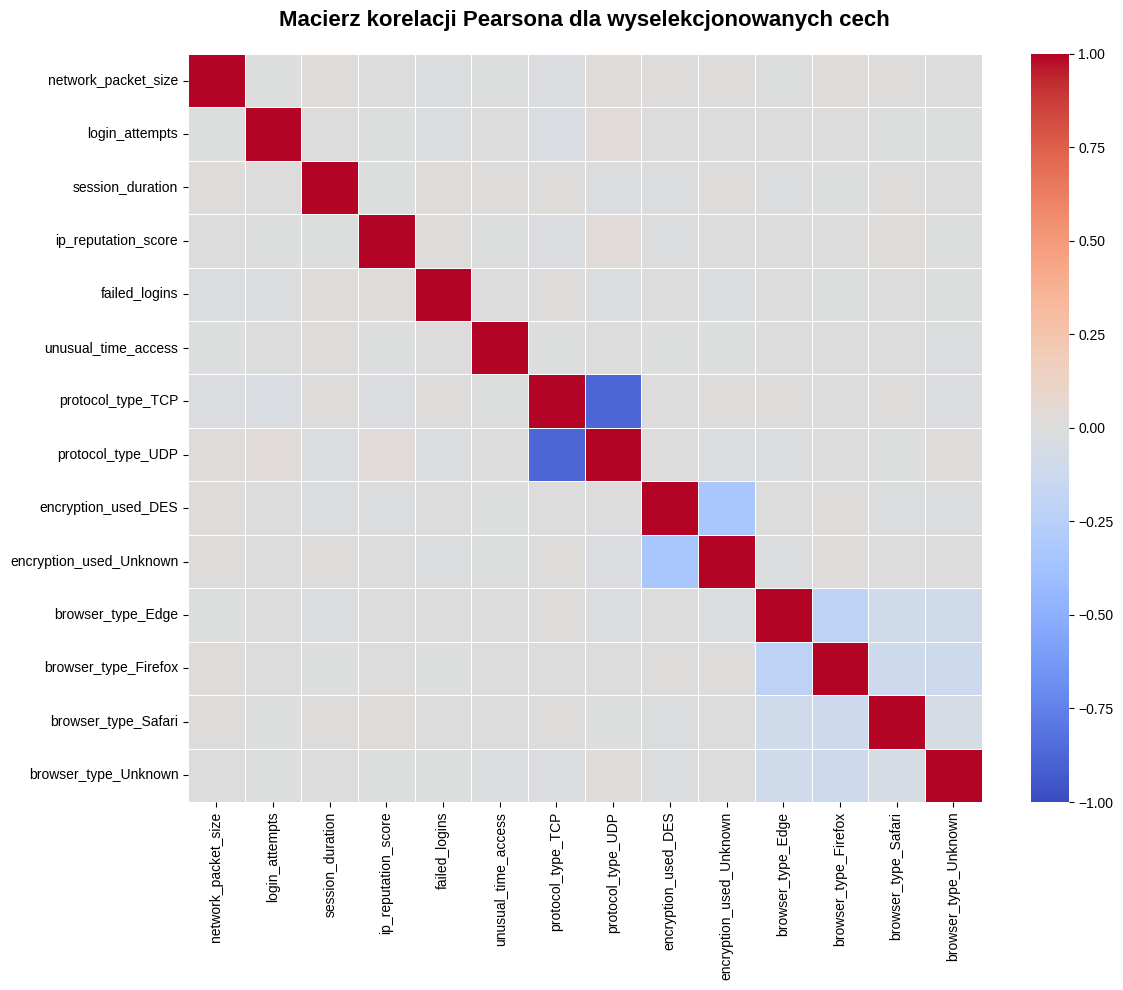

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = X.corr()

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Calibri', 'Arial', 'Liberation Sans', 'DejaVu Sans']

plt.figure(figsize=(12, 10))

sns.heatmap(corr_matrix,
            annot=False,
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            center=0,
            linewidths=0.5,
            linecolor='white')

plt.title('Macierz korelacji Pearsona dla wyselekcjonowanych cech', fontsize=16, pad=20, weight='bold')
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/cybersec_ml_mgr/heatmap_korelacji_cech.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()

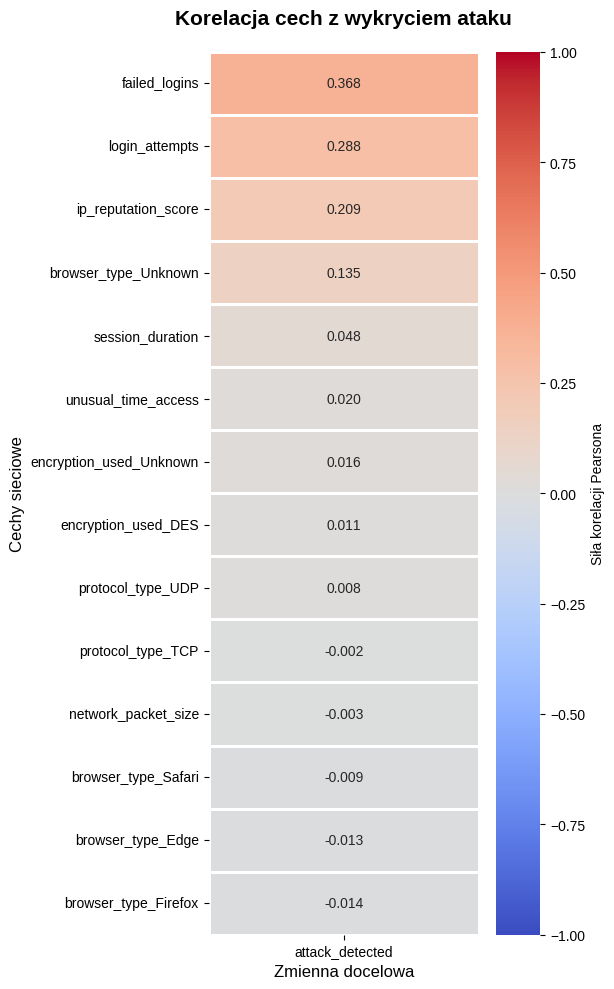

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

df_analiza = X_train.copy()
df_analiza['attack_detected'] = y_train

korelacja_z_celem = df_analiza.corr()[['attack_detected']].sort_values(by='attack_detected', ascending=False)

korelacja_z_celem = korelacja_z_celem.drop('attack_detected')

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Calibri', 'Arial', 'Liberation Sans', 'DejaVu Sans']

plt.figure(figsize=(6, 10))

sns.heatmap(korelacja_z_celem,
            annot=True,
            fmt='.3f',
            cmap='coolwarm',
            vmin=-1,
            vmax=1,
            linewidths=1,
            linecolor='white',
            cbar_kws={'label': 'Siła korelacji Pearsona'})

plt.title('Korelacja cech z wykryciem ataku', fontsize=15, pad=20, weight='bold')
plt.ylabel('Cechy sieciowe', fontsize=12)
plt.xlabel('Zmienna docelowa', fontsize=12)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Colab Notebooks/cybersec_ml_mgr/korelacja_z_wykryciem_ataku.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
plt.close()


In [ ]:
folder_path = '/content/drive/MyDrive/Colab Notebooks/cybersec_ml_mgr/'

X_train_scaled.to_csv(folder_path + 'X_train.csv', index=False)
X_test_scaled.to_csv(folder_path + 'X_test.csv', index=False)
y_train.to_csv(folder_path + 'y_train.csv', index=False)
y_test.to_csv(folder_path + 'y_test.csv', index=False)

print("Przygotowane dane zostały zapisane na dysku.")

Przygotowane dane zostały zapisane na dysku.
